In [1]:
import scanpy as sc
import pandas as pd
from tripso.Evaluate.downstream import calculate_gene_significance, plot_top_genes
import numpy as np
import anndata as ad
import os

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [3]:
def load_adata(run, output_name = 'global'):
    holder = []
    base_path = 'tripso_reproducibility/04.4_HSC_fix_hvg'
    

    for t in ['train', 'val', 'test']:
        target_path = f'gene_embedding_analysis/PI3K_sakurai_hspc/PI3K_gene_embeddings_HSPC-HLF_HSPC-Cycling_HSPC/gene_to_PI3K_cosine_similarity_{t}_set.h5ad'
        holder.append(
            sc.read_h5ad(os.path.join(base_path, f'{run}_by_study/output_{output_name}', target_path))
        )
        
    adata = ad.concat(holder)    
    
    return adata


In [4]:
run1 = load_adata('run_1')
run2 = load_adata('run_2')
run3 = load_adata('run_3')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [5]:
# sanity check
print(run1.obs == run2.obs)
print(run2.obs == run3.obs)
print(run1.var == run2.var)
print(run3.var == run3.var)

     length  scaled_length  condition  Phase  seurat_clusters  cell_type  \
0      True           True       True   True             True       True   
1      True           True       True   True             True       True   
2      True           True       True   True             True       True   
3      True           True       True   True             True       True   
4      True           True       True   True             True       True   
..      ...            ...        ...    ...              ...        ...   
802    True           True       True   True             True       True   
803    True           True       True   True             True       True   
804    True           True       True   True             True       True   
805    True           True       True   True             True       True   
806    True           True       True   True             True       True   

     source  n_counts  study  tissue   idx  batch_key  source_id  \
0      True      Tr

In [6]:
adata = sc.AnnData(
    X = (run1.X + run2.X + run3.X)/3,
    obs = run1.obs,
    var = run1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [7]:
# map ensembl to gene name 
from geneformer import ENSEMBL_DICTIONARY_FILE
name_to_ens = pd.read_pickle(ENSEMBL_DICTIONARY_FILE)
name_df = pd.DataFrame(
            list(name_to_ens.items()), columns=['gene', 'ensembl_id']
        )

convert_df = name_df[name_df['ensembl_id'].isin(adata.var_names)]

# gpdb_symbol = pd.read_csv('../../gp_nw_all.csv')
gpdb_symbol = pd.read_csv('tripso_reproducibility/02.1_benchmarking_repeat/gpdb_progeny_200.csv')

convert_df = convert_df[convert_df['gene'].isin(gpdb_symbol['PI3K'].values)]

In [8]:
adata.var = adata.var.join(convert_df.set_index('ensembl_id'))

In [9]:
adata.var = adata.var.set_index('gene')

In [10]:
# AnnData (sparse native, zeros treated as 0)
res = calculate_gene_significance(
    adata,
    obs_col="condition",
    obs_value_ref="Soluplus",
    obs_value_query="UM171",
    adata_gene_threshold=0.9,   # same semantics as before
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2308: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


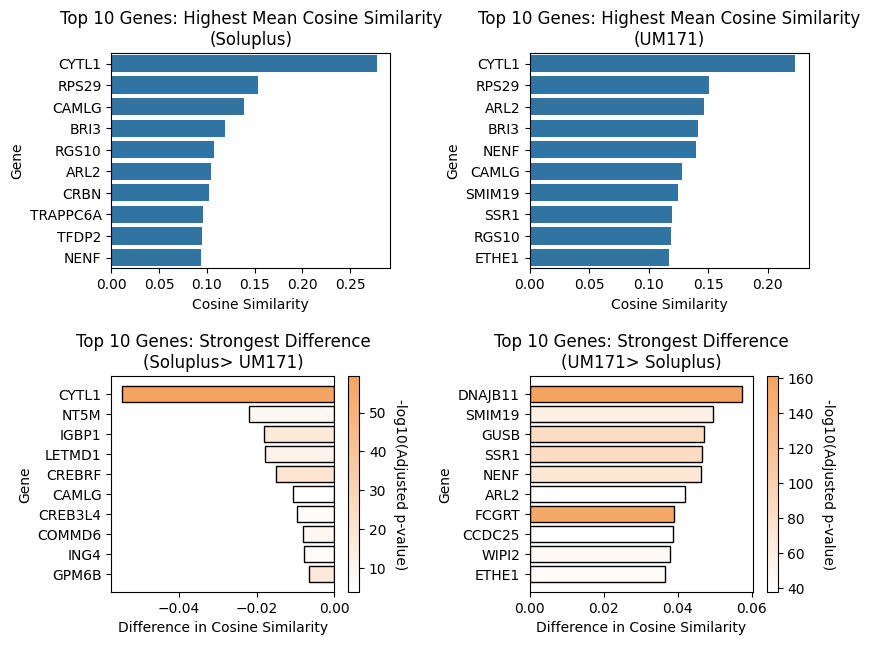

In [11]:
plot_top_genes(
    res,
    obs_value_ref="Soluplus",
    obs_value_query="UM171",
    show_significance=False,
    color_scheme='significance',
    significance_palette=['sandybrown', 'sandybrown'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize=(9, 7),
     save_to = 'pi3k_um171_soluplus.pdf'
)


In [12]:
# AnnData (sparse native, zeros treated as 0)
res = calculate_gene_significance(
    adata,
    obs_col="condition",
    obs_value_ref="Soluplus",
    obs_value_query="SR1",
    adata_gene_threshold=0.9,   # same semantics as before
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2308: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


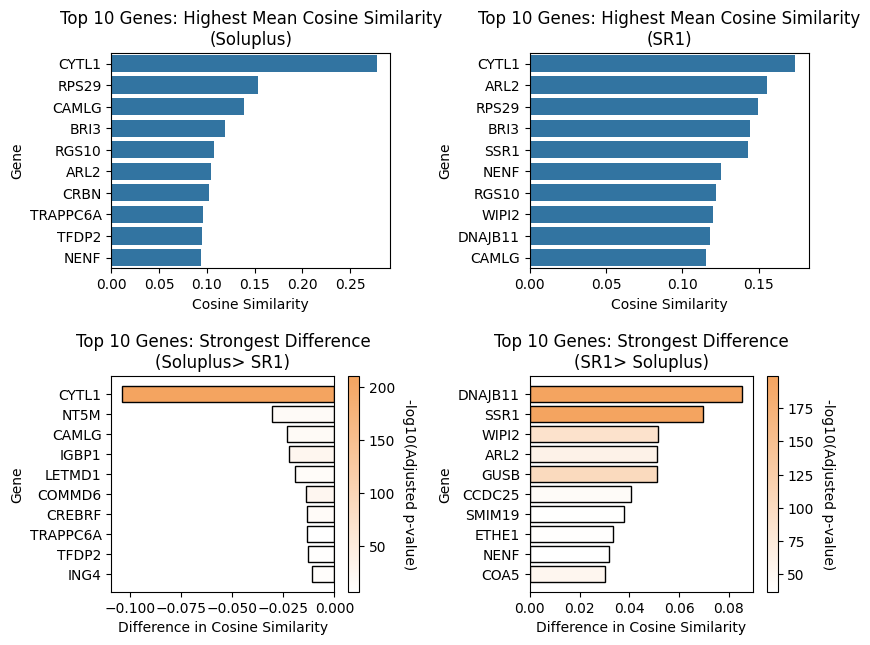

In [13]:
plot_top_genes(
    res,
    obs_value_ref="Soluplus",
    obs_value_query="SR1",
    show_significance=False,
    color_scheme='significance',
    significance_palette=['sandybrown', 'sandybrown'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize=(9, 7),
    save_to='pi3k_sr1_soluplus.pdf'
)
